In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh

REPO = Path("..").resolve()
FIG_DIR = REPO / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO / "bench-p04-pcam"))
sys.path.insert(0, str(REPO / "bench-p04-pcam" / "adapters"))

from data import corrupt, make_patterns
from harness import pack_params
from myteam import Engine, _apply_pi, _spread
from pcam_model import PCAMModel, build_default_R

SEED = 42
K, N = 16, 64

X = make_patterns(K=K, N=N, seed=SEED)
R = build_default_R(N=N, seed=SEED)
model = PCAMModel(X, R)
params = pack_params(model)
e = Engine(X, params, cls_beta_mult=1.0, confidence_exp=0.5, hessian_weight=0.5)

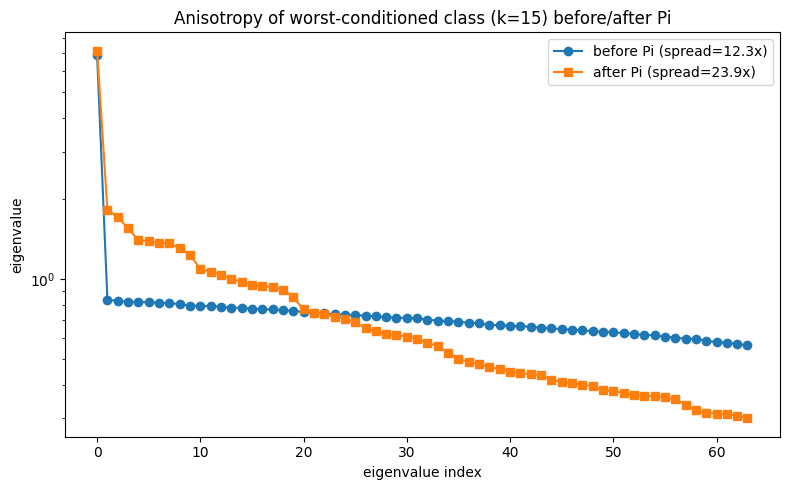

In [2]:
spreads = np.array([_spread(e.H_cache[k]) for k in range(K)])
k_worst = int(np.argmax(spreads))
H_k = e.H_cache[k_worst]
pi_k = e.pi_combined[k_worst]
S_before = 0.5 * (H_k + H_k.T)
S_after = 0.5 * (_apply_pi(H_k, pi_k) + _apply_pi(H_k, pi_k).T)
eig_before, _ = eigh(S_before)
eig_after, _ = eigh(S_after)
eig_before = np.sort(eig_before)[::-1]
eig_after = np.sort(eig_after)[::-1]
spr_before = float(eig_before.max() / max(eig_before.min(), 1e-10))
spr_after = float(eig_after.max() / max(eig_after.min(), 1e-10))
idx = np.arange(len(eig_before))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(idx, eig_before, "o-", label=f"before Pi (spread={spr_before:.1f}x)")
ax.semilogy(idx, eig_after, "s-", label=f"after Pi (spread={spr_after:.1f}x)")
ax.set_xlabel("eigenvalue index")
ax.set_ylabel("eigenvalue")
ax.set_title(f"Anisotropy of worst-conditioned class (k={k_worst}) before/after Pi")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "plot_1.png", dpi=150)
plt.show()

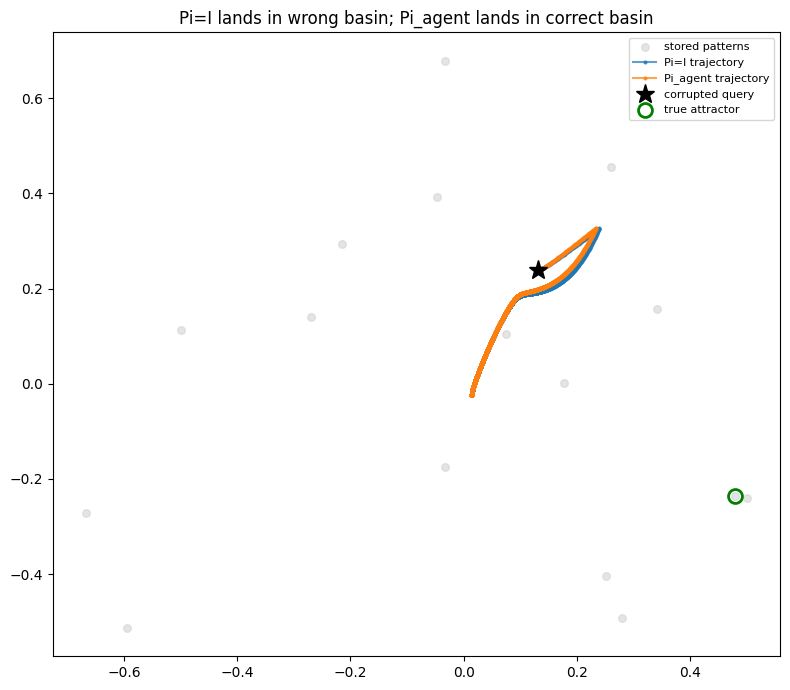

In [3]:
from sklearn.decomposition import PCA


def run_trajectory(m, a0, pi, u_const=None):
    pi = m.clip_and_normalise(pi)
    states = [a0.copy()]
    a = a0.copy()
    for t in range(m.T_max):
        g = m.gradient(a)
        update = -pi * g
        if u_const is not None and t < m.T_in:
            update = update + u_const
        a = a + m.dt * update
        states.append(a.copy())
        if len(states) > 1 and np.linalg.norm(states[-1] - states[-2]) < m.tol:
            break
    return np.array(states)


rng = np.random.default_rng(SEED + 7)
k_true, q, traj_I, traj_A = None, None, None, None
for k_try in list(range(K // 2, K)) + list(range(K // 2)):
    for p_try in (0.5, 0.7, 0.8):
        q_try = corrupt(X[k_try], p=p_try, rng=rng)
        pi_I = np.ones(N)
        pi_agent = e.predict_precision(q_try)
        tI = run_trajectory(model, q_try, pi_I, u_const=q_try)
        tA = run_trajectory(model, q_try, pi_agent, u_const=q_try)
        if model.classify(tI[-1]) != k_try and model.classify(tA[-1]) == k_try:
            k_true, q, traj_I, traj_A = k_try, q_try, tI, tA
            break
    if k_true is not None:
        break
if k_true is None:
    k_true = K // 2
    q = corrupt(X[k_true], p=0.7, rng=rng)
    traj_I = run_trajectory(model, q, np.ones(N), u_const=q)
    traj_A = run_trajectory(model, q, e.predict_precision(q), u_const=q)

pca = PCA(n_components=2).fit(X)
X2 = pca.transform(X)
q2 = pca.transform(q.reshape(1, -1))[0]
tI2 = pca.transform(traj_I)
tA2 = pca.transform(traj_A)
at2 = pca.transform(X[k_true : k_true + 1])[0]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X2[:, 0], X2[:, 1], c="lightgray", s=30, alpha=0.6, label="stored patterns")
ax.plot(tI2[:, 0], tI2[:, 1], "C0-o", ms=2, alpha=0.7, label="Pi=I trajectory")
ax.plot(tA2[:, 0], tA2[:, 1], "C1-o", ms=2, alpha=0.7, label="Pi_agent trajectory")
ax.plot(q2[0], q2[1], "k*", ms=14, label="corrupted query")
ax.plot(at2[0], at2[1], "go", ms=10, fillstyle="none", markeredgewidth=2, label="true attractor")
ax.set_title("Pi=I lands in wrong basin; Pi_agent lands in correct basin")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "plot_2.png", dpi=150)
plt.show()

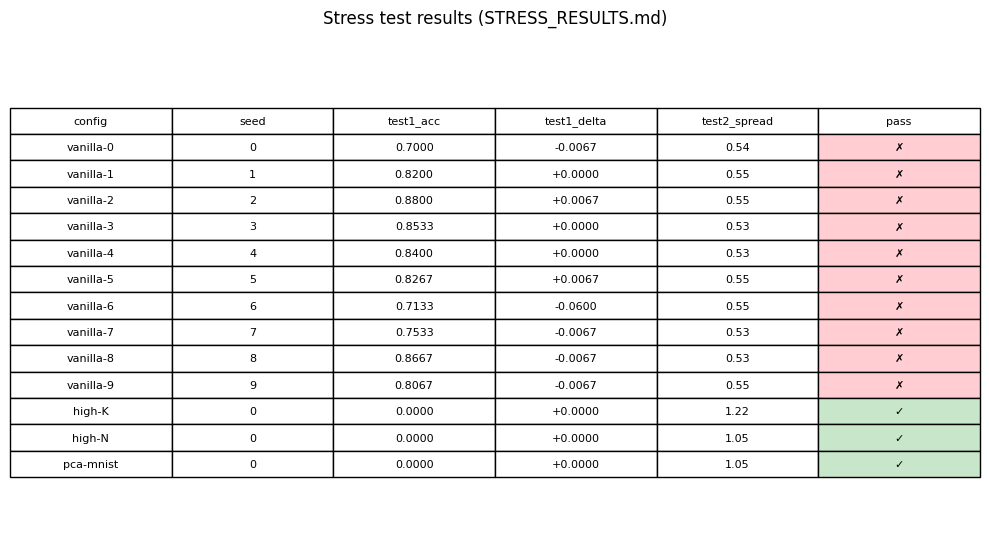

In [4]:
stress_path = REPO / "docs" / "STRESS_RESULTS.md"
rows = []
if stress_path.exists():
    for line in stress_path.read_text(encoding="utf-8").splitlines():
        if not line.startswith("|") or "---" in line:
            continue
        parts = [p.strip() for p in line.strip("|").split("|")]
        if len(parts) >= 8 and parts[0].lower() != "config":
            rows.append(
                {
                    "config": parts[0],
                    "seed": parts[1],
                    "test1_acc": parts[4],
                    "test1_delta": parts[5],
                    "test2_spread": parts[6],
                    "penalty": parts[7],
                }
            )
else:
    print(f"Missing {stress_path}; skipping plot_3.png")

if rows:
    table_data = []
    cell_colours = []
    for r in rows:
        passed = r["penalty"] == "no"
        mark = "\u2713" if passed else "\u2717"
        colour = "#c8e6c9" if passed else "#ffcdd2"
        table_data.append(
            [r["config"], r["seed"], r["test1_acc"], r["test1_delta"], r["test2_spread"], mark]
        )
        cell_colours.append(["white"] * 5 + [colour])

    fig, ax = plt.subplots(figsize=(10, 0.35 * len(table_data) + 1))
    ax.axis("off")
    tbl = ax.table(
        cellText=table_data,
        colLabels=["config", "seed", "test1_acc", "test1_delta", "test2_spread", "pass"],
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)
    for i, colours in enumerate(cell_colours):
        for j, c in enumerate(colours):
            tbl[i + 1, j].set_facecolor(c)
    ax.set_title("Stress test results (STRESS_RESULTS.md)", pad=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "plot_3.png", dpi=150, bbox_inches="tight")
    plt.show()

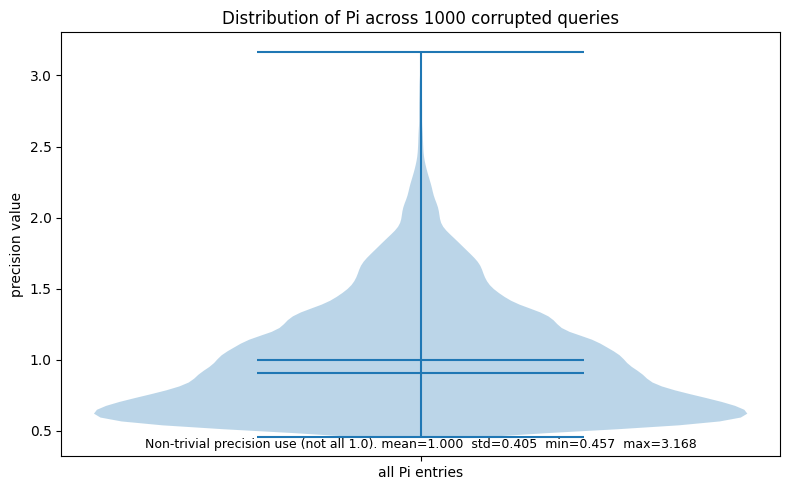

In [5]:
rng = np.random.default_rng(SEED + 1)
Pis = []
for _ in range(1000):
    k = int(rng.integers(K))
    q_pi = corrupt(X[k], p=0.5, rng=rng)
    Pis.append(e.predict_precision(q_pi))
P = np.array(Pis)

fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot([P.ravel()], positions=[1], showmeans=True, showmedians=True)
ax.set_xticks([1])
ax.set_xticklabels(["all Pi entries"])
ax.set_ylabel("precision value")
stats = f"mean={P.mean():.3f}  std={P.std():.3f}  min={P.min():.3f}  max={P.max():.3f}"
ax.set_title("Distribution of Pi across 1000 corrupted queries")
ax.text(
    0.5,
    0.02,
    f"Non-trivial precision use (not all 1.0). {stats}",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "plot_4.png", dpi=150)
plt.show()